# exp_analysis_0321

这个 notebook 把 analytic step 动力学例子与 Kuramoto 0321 中的通用白化 Koopman 主链结合起来。

它包含五个部分：参数影响实验、解析 K 的统一矩阵分析、带标准正态噪声的白化 Koopman 主链、K_bar 上的 SVD/EVD 对比，以及解析 K 与白化 K_bar 的总体对比。


In [16]:
import sys
from pathlib import Path

REPO_ROOT = None
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (candidate / 'tools' / 'tools.py').exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError('Could not locate repository root containing tools/tools.py')
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import types
try:
    import plotly.express as _px  # noqa: F401
    import plotly.graph_objects as _go  # noqa: F401
except ModuleNotFoundError:
    plotly_module = types.ModuleType('plotly')
    express_module = types.ModuleType('plotly.express')
    graph_objects_module = types.ModuleType('plotly.graph_objects')
    plotly_module.express = express_module
    plotly_module.graph_objects = graph_objects_module
    sys.modules['plotly'] = plotly_module
    sys.modules['plotly.express'] = express_module
    sys.modules['plotly.graph_objects'] = graph_objects_module

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap
import seaborn as sns
import pysindy as ps
from IPython.display import display
from sympy import symbols, Matrix, sqrt, simplify

from tools import (
    compute_transition_covariances,
    fit_data_koopman_operator,
    get_positive_contributions,
    compute_entropy,
    init_artifacts,
    analyze_kbar_metrics,
    build_macro_from_kbar,
    print_summary,
    compute_gamma_ce_metrics,
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 160
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = [
    'Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Source Han Sans SC', 'Arial Unicode MS', 'DejaVu Sans'
]
HEATMAP_CMAP = 'vlag'

_ORIGINAL_SHOW = plt.show
def _show_and_close(*args, **kwargs):
    _ORIGINAL_SHOW(*args, **kwargs)
    plt.close('all')
plt.show = _show_and_close


def sparse_labels(labels, step=1):
    if labels is None:
        return False
    if step <= 1:
        return labels
    return [label if idx % step == 0 else '' for idx, label in enumerate(labels)]


def plot_matrix_heatmap(matrix, title, row_labels=None, col_labels=None, center=0.0, figsize=(6, 6), label_step=1, cmap=HEATMAP_CMAP):
    matrix = np.asarray(matrix)
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(matrix, ax=ax, cmap=cmap, center=center, square=matrix.shape[0] == matrix.shape[1], xticklabels=sparse_labels(col_labels, label_step), yticklabels=sparse_labels(row_labels, label_step))
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def standardize_for_plot(x):
    x = np.asarray(x, dtype=float)
    return (x - np.mean(x)) / (np.std(x) + 1e-12)


def print_linear_combination(coeffs, feature_names, target_names, threshold=1e-8):
    coeffs = np.asarray(coeffs)
    rows, cols = coeffs.shape
    for j in range(cols):
        terms = []
        for i in range(rows):
            val = coeffs[i, j]
            if abs(val) > threshold:
                terms.append(f'{val:.4f} * {feature_names[i]}')
        rhs = ' + '.join(terms) if terms else '0'
        print(f'{target_names[j]} = {rhs}')
        print('-' * 40)


def compute_singular_values(lam, mu):
    A = np.array([[lam, 0.0, 0.0], [0.0, mu, lam**2 - mu], [0.0, 0.0, lam**2]], dtype=float)
    sv = np.linalg.svd(A, compute_uv=False)
    sv = np.sort(sv)[::-1]
    return sv[0], sv[1], sv[2], A


def generate_data_and_analyze(lam_values=None, log_min=-4, log_max=4, n_points=200):
    if lam_values is None:
        lam_values = [0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0, 10.0]
    log_ratios = np.linspace(log_min, log_max, n_points)
    ratios = 10 ** log_ratios
    results = {}
    for lam in lam_values:
        results[lam] = {'ratios': ratios, 'sv1': [], 'sv2': [], 'sv3': []}
        for ratio in ratios:
            mu = lam / ratio
            sv1, sv2, sv3, _ = compute_singular_values(lam, mu)
            results[lam]['sv1'].append(sv1)
            results[lam]['sv2'].append(sv2)
            results[lam]['sv3'].append(sv3)
    return results, lam_values, ratios


def plot_singular_values_boxplot(results, lam_values, ratios):
    data_list = []
    for lam in lam_values:
        res = results[lam]
        for i, ratio in enumerate(ratios):
            ratio_label = f"$10^{{{np.log10(ratio):.0f}}}$"
            data_list.append({'Ratio': ratio_label, 'Singular Value': res['sv1'][i], 'Type': '$\sigma_1$'})
            data_list.append({'Ratio': ratio_label, 'Singular Value': res['sv2'][i], 'Type': '$\sigma_2$'})
            data_list.append({'Ratio': ratio_label, 'Singular Value': res['sv3'][i], 'Type': '$\sigma_3$'})
    df = pd.DataFrame(data_list)
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df, x='Ratio', y='Singular Value', hue='Type', palette='Set2')
    plt.yscale('log')
    plt.xlabel('$\lambda/\mu$ ratio')
    plt.ylabel('Singular value')
    plt.tight_layout()
    plt.show()


## 1. 参数影响实验：考察不同参数下奇异值谱如何变化

这一部分保留原 analytic example 的参数扫描思路。目标是观察当 $\lambda$ 和 $\mu$ 改变时，3 维解析矩阵的奇异值谱是否会出现明显分离。


In [17]:
lambda_, mu_symbol = symbols('lambda mu', real=True)
A_symbolic = Matrix([[lambda_, 0, 0], [0, mu_symbol, lambda_**2 - mu_symbol], [0, 0, lambda_**2]])
A_symbolic_TA = A_symbolic.T * A_symbolic
symbolic_eigs = [simplify(v) for v in A_symbolic_TA.eigenvals(multiple=True)]
symbolic_sv = [simplify(sqrt(v)) for v in symbolic_eigs]
print('奇异值的解析表达式：')
for idx, expr in enumerate(symbolic_sv, start=1):
    print(f'sigma_{idx} = {expr}')


奇异值的解析表达式：
sigma_1 = Abs(lambda)
sigma_2 = sqrt(lambda**4 - lambda**2*mu + mu**2 + (lambda**2 - mu)*sqrt(lambda**4 + mu**2))
sigma_3 = sqrt(lambda**4 - lambda**2*mu + mu**2 - (lambda**2 - mu)*sqrt(lambda**4 + mu**2))


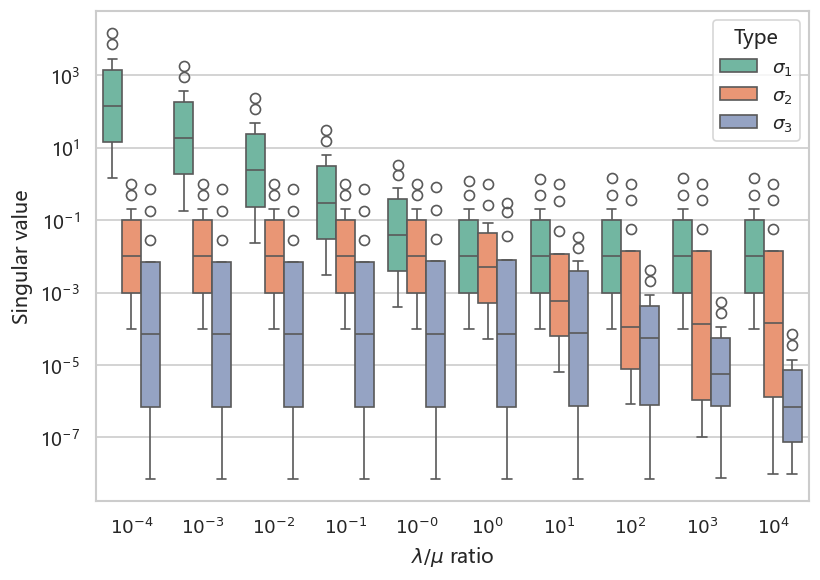

In [18]:
results, lam_values, ratios = generate_data_and_analyze(
    lam_values=[0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0],
    log_min=-4,
    log_max=4,
    n_points=10,
)
plot_singular_values_boxplot(results, lam_values, ratios)


In [19]:
def step(x, y, lam, mu):
    x_next = lam * x
    y_next = mu * y + (lam**2 - mu) * x**2
    return x_next, y_next


def gen_step_data(initial_x=5.0, initial_y=5.0, lam=0.1, mu=0.9, total_steps=200, dt=1.0):
    t = np.arange(0, total_steps * dt, dt)
    x_vals = np.zeros(len(t))
    y_vals = np.zeros(len(t))
    x_vals[0], y_vals[0] = initial_x, initial_y
    for i in range(1, len(t)):
        x_vals[i] = lam * x_vals[i - 1]
        y_vals[i] = mu * y_vals[i - 1] + (lam**2 - mu) * (x_vals[i - 1] ** 2)
    data = np.column_stack([x_vals, y_vals])
    return data, t


def add_standard_normal_noise(data, noise_scale=0.05, random_seed=None):
    rng = np.random.default_rng(random_seed)
    base_noise = rng.standard_normal(size=np.asarray(data).shape)
    data_noisy = np.asarray(data, dtype=float) + noise_scale * base_noise
    return data_noisy, base_noise


def gen_step_data_with_noise(initial_x=5.0, initial_y=5.0, lam=0.1, mu=0.9, total_steps=200, dt=1.0, noise_scale=0.05, random_seed=None):
    data_clean, t = gen_step_data(initial_x=initial_x, initial_y=initial_y, lam=lam, mu=mu, total_steps=total_steps, dt=dt)
    data_noisy, base_noise = add_standard_normal_noise(data_clean, noise_scale=noise_scale, random_seed=random_seed)
    return data_clean, data_noisy, base_noise, t


### 参数固定时的相图展示

这里参考 `examp_analysis.ipynb` 中的渐变轨迹画法，在固定参数下从多个不同初始点出发，用渐变轨迹展示 step 系统在相空间中的收缩路径。


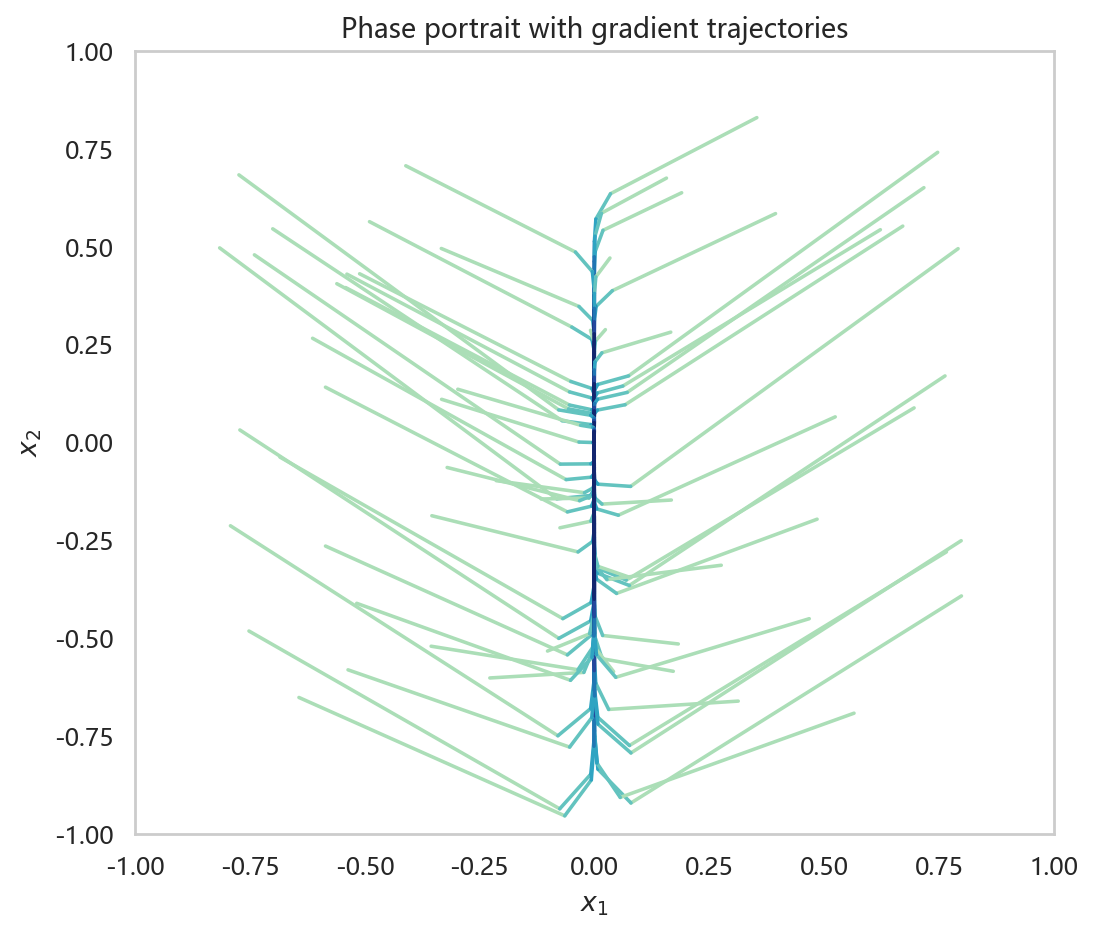

In [20]:
lam_phase, mu_phase = 0.1, 0.9
iterations = 35
num_samples = 60
np.random.seed(42)
x1_init = np.random.uniform(-0.85, 0.85, num_samples)
x2_init = np.random.uniform(-0.7, 0.85, num_samples)
initial_points = np.vstack([x1_init, x2_init]).T

fig, ax = plt.subplots(figsize=(7, 6), dpi=160)
full_cmap = plt.cm.YlGnBu
colors = full_cmap(np.linspace(0.3, 0.95, 6))
custom_cmap = ListedColormap(colors)

for x0, y0 in initial_points:
    xs, ys = [x0], [y0]
    curr_x, curr_y = x0, y0
    for _ in range(iterations):
        curr_x, curr_y = step(curr_x, curr_y, lam_phase, mu_phase)
        xs.append(curr_x)
        ys.append(curr_y)
    points = np.array([xs, ys]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    color_indices = np.arange(len(segments))
    color_indices[5:] = 5
    lc = LineCollection(segments, cmap=custom_cmap)
    lc.set_array(color_indices)
    lc.set_linewidth(1.6)
    lc.set_capstyle('round')
    lc.set_alpha(1.0)
    ax.add_collection(lc)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Phase portrait with gradient trajectories')
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.grid(False)
plt.tight_layout()
plt.show()


## 2. 已知解析 K 时的统一矩阵分析

这一部分的 K 是由给定参数直接解析写出的。但是，后续的指标体系尽量与 Kuramoto 0321 的通用主链保持一致：我们会对这个解析 K 直接计算奇异值谱、EC、D_K、N_K、G_alpha^K、Gamma_alpha^K、gamma_alpha^K 与 CE，并构造粗粒化变量。


In [21]:
direct_config = {
    'lam': 0.1,
    'mu': 0.9,
    'rank': 1,
    'alpha': 1.0,
    'eps': 1e-10,
    'initial_x': 5.0,
    'initial_y': 5.0,
    'total_steps': 500,
    'dt': 1.0,
}

_, _, _, K_direct = compute_singular_values(direct_config['lam'], direct_config['mu'])
direct_feature_names = ['$x_1$', '$x_2$', '${x_1}^2$']
direct_metrics = analyze_kbar_metrics(K_direct, alpha=direct_config['alpha'], eps=direct_config['eps'])
direct_diff = get_positive_contributions(direct_metrics['S'])
direct_EC = compute_entropy(direct_diff)
direct_gamma = compute_gamma_ce_metrics(direct_metrics['S'], alpha=direct_config['alpha'], manual_r=direct_config['rank'], eps=direct_config['eps'])
direct_rank = direct_gamma['manual_r']
direct_U = direct_metrics['U']
direct_coarse = direct_U[:, :direct_rank]
direct_macro_names = [f'y_{i+1}' for i in range(direct_rank)]

direct_data, direct_t = gen_step_data(initial_x=direct_config['initial_x'], initial_y=direct_config['initial_y'], lam=direct_config['lam'], mu=direct_config['mu'], total_steps=direct_config['total_steps'], dt=direct_config['dt'])
direct_x1 = direct_data[:, 0]
direct_x2 = direct_data[:, 1]
direct_lift = np.column_stack([direct_x1, direct_x2, direct_x1 ** 2])
direct_macro_series = direct_lift @ direct_coarse
direct_macro_matrix = direct_coarse.T @ K_direct @ direct_coarse

print('Direct K shape:', K_direct.shape)
print('Top singular values of direct K:', direct_metrics['S'])
print('EC of direct K:', direct_EC)
print('G_alpha^K of direct K:', direct_metrics['G_alpha_K'])
print('Selected r from CE:', direct_gamma['selected_r'])
print('Delta Gamma at manual r:', direct_gamma['delta_gamma_manual_r'])


Direct K shape: (3, 3)
Top singular values of direct K: [1.26576042 0.1        0.00711035]
EC of direct K: 0.9998656418509548
G_alpha^K of direct K: -3.6193439825916665
Selected r from CE: 1
Delta Gamma at manual r: 0.8081368304445518


### 解析 K 的矩阵指标与粗粒化

这里先展示解析 K 的矩阵、奇异值谱、EC increments 、D_K、N_K 以及 CE 曲线，然后用左奇异向量构造粗粒化变量。


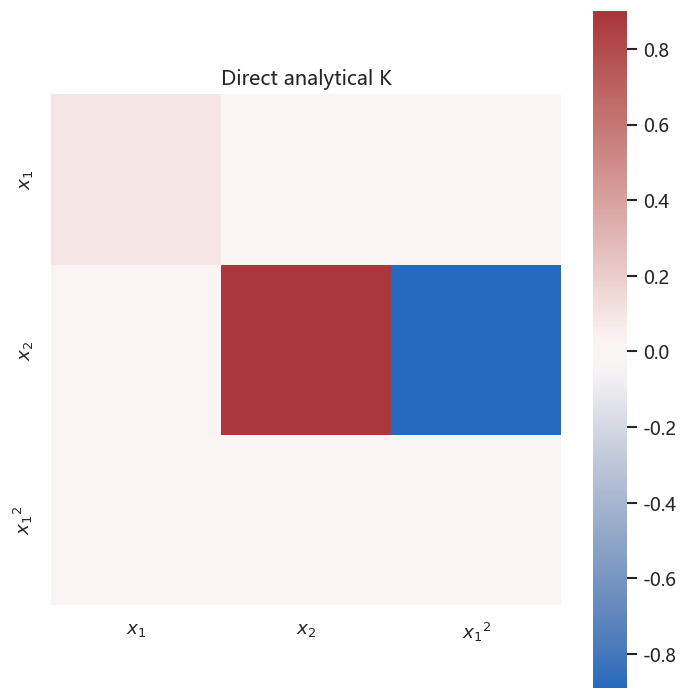

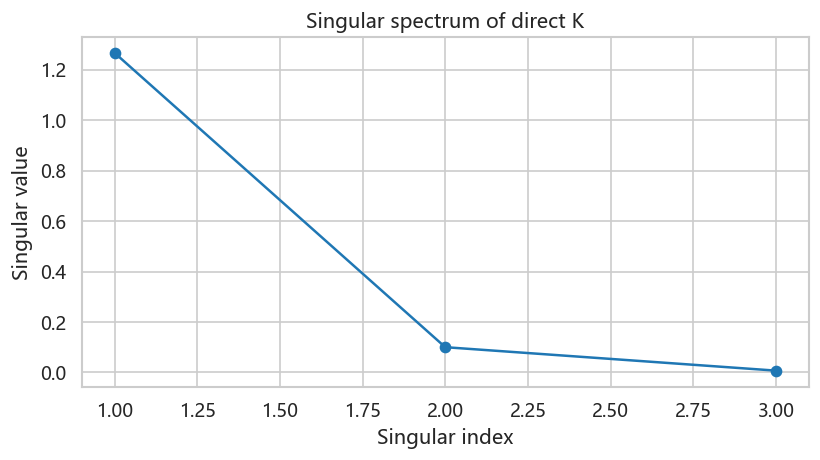

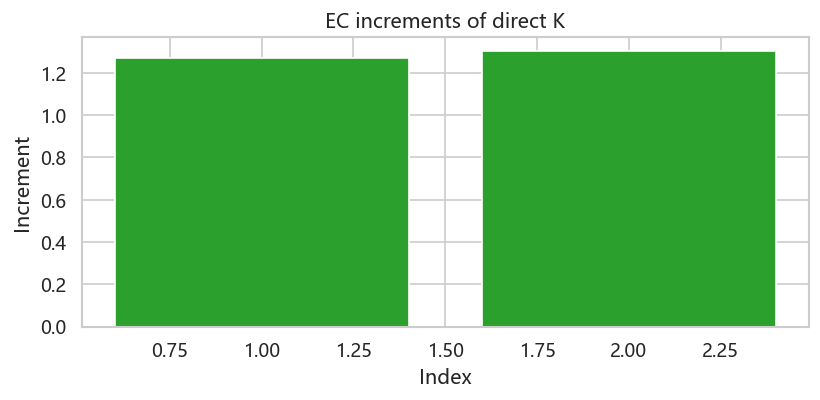

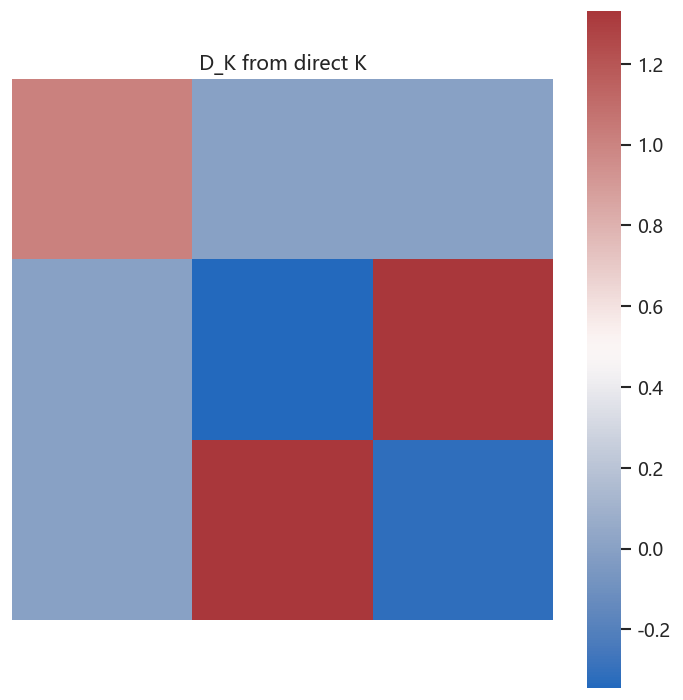

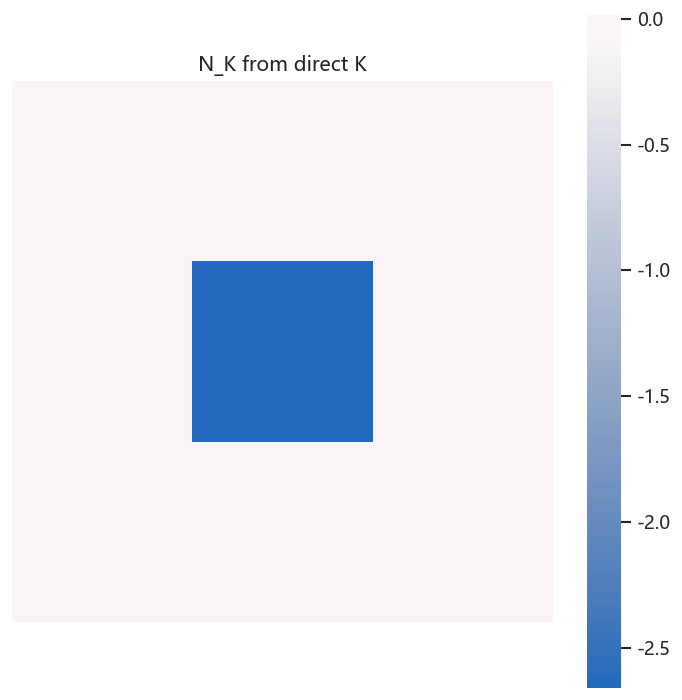

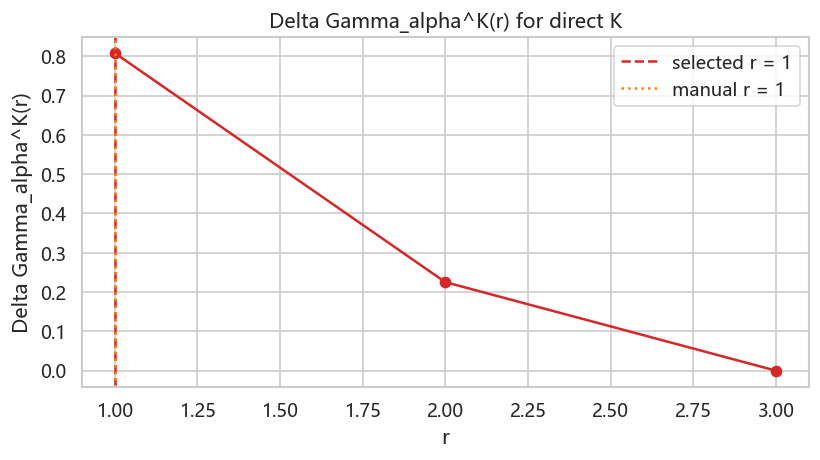

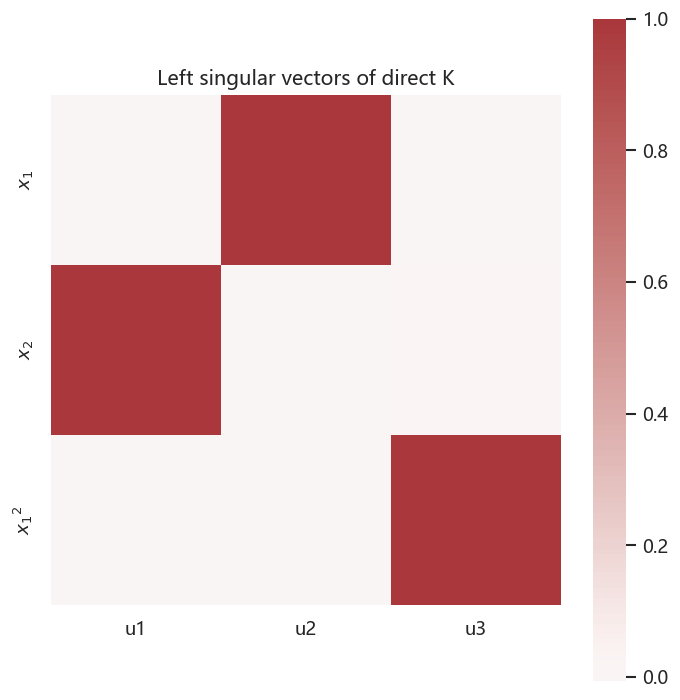

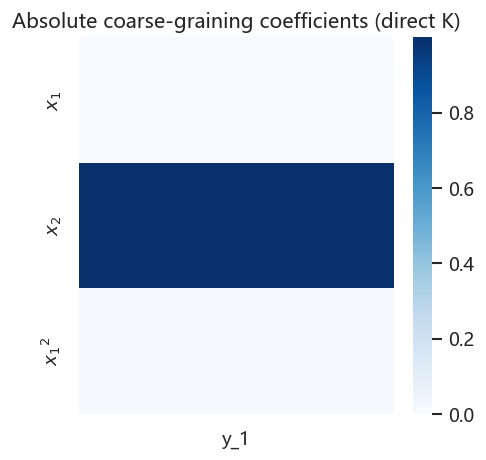

Direct coarse-graining expressions:
y_1 = 1.0000 * $x_2$ + -0.0056 * ${x_1}^2$
----------------------------------------
Direct macro evolution equation:
y_1[k+1] = 0.9049 * y_1
----------------------------------------


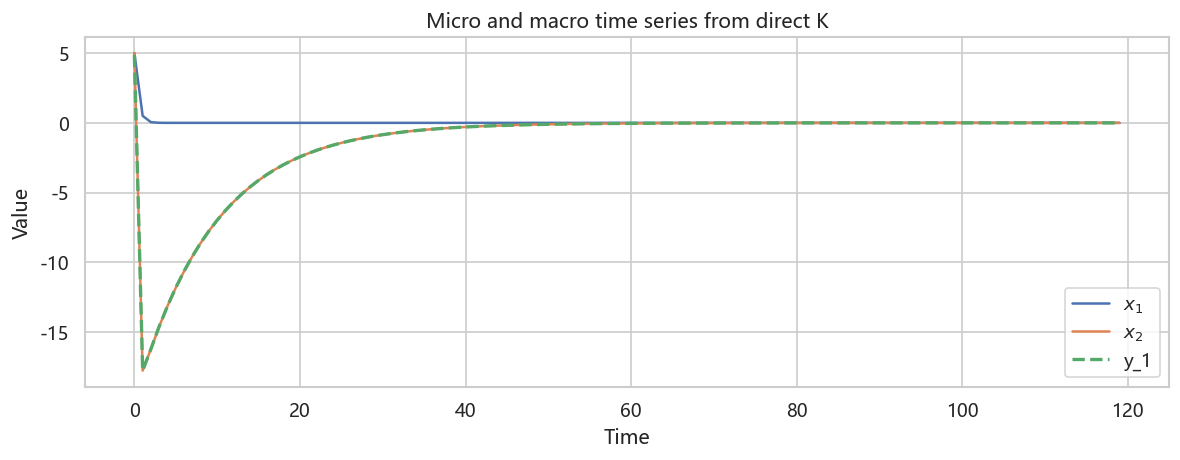

In [22]:
plot_matrix_heatmap(K_direct, 'Direct analytical K', row_labels=direct_feature_names, col_labels=direct_feature_names, label_step=1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, len(direct_metrics['S']) + 1), direct_metrics['S'], marker='o', color='tab:blue')
ax.set_title('Singular spectrum of direct K')
ax.set_xlabel('Singular index')
ax.set_ylabel('Singular value')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(np.arange(1, len(direct_diff) + 1), direct_diff, color='tab:green')
ax.set_title('EC increments of direct K')
ax.set_xlabel('Index')
ax.set_ylabel('Increment')
plt.tight_layout()
plt.show()

plot_matrix_heatmap(direct_metrics['D_K'], 'D_K from direct K', center=None, label_step=1)
plot_matrix_heatmap(direct_metrics['N_K'], 'N_K from direct K', center=0.0, label_step=1)

plt.figure(figsize=(7, 4))
plt.plot(list(direct_gamma['delta_gamma_by_r'].keys()), list(direct_gamma['delta_gamma_by_r'].values()), marker='o', color='tab:red')
plt.axvline(direct_gamma['selected_r'], color='tab:red', linestyle='--', label=f"selected r = {direct_gamma['selected_r']}")
plt.axvline(direct_rank, color='tab:orange', linestyle=':', label=f"manual r = {direct_rank}")
plt.title('Delta Gamma_alpha^K(r) for direct K')
plt.xlabel('r')
plt.ylabel('Delta Gamma_alpha^K(r)')
plt.legend()
plt.tight_layout()
plt.show()

plot_matrix_heatmap(direct_U, 'Left singular vectors of direct K', row_labels=direct_feature_names, col_labels=[f'u{i+1}' for i in range(direct_U.shape[1])], label_step=1)
plot_matrix_heatmap(np.abs(direct_coarse), 'Absolute coarse-graining coefficients (direct K)', row_labels=direct_feature_names, col_labels=direct_macro_names, center=None, figsize=(4, 4), label_step=1, cmap='Blues')

print('Direct coarse-graining expressions:')
print_linear_combination(direct_coarse, direct_feature_names, direct_macro_names)
print('Direct macro evolution equation:')
print_linear_combination(direct_macro_matrix, direct_macro_names, [f'{name}[k+1]' for name in direct_macro_names])

plt.figure(figsize=(10, 4))
plt.plot(direct_t[:120], direct_x1[:120], label='$x_1$')
plt.plot(direct_t[:120], direct_x2[:120], label='$x_2$')
for i in range(direct_rank):
    plt.plot(direct_t[:120], direct_macro_series[:120, i], '--', linewidth=2.0, label=f'{direct_macro_names[i]}')
plt.title('Micro and macro time series from direct K')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()


## 3. 生成带标准正态噪声的数据，并按照白化 Koopman 主链分析

这一部分保留 analytic step 系统的数据生成背景，但分析方法改成 Kuramoto 0321 中的白化 Koopman 主链。数据在干净 step 轨道上叠加标准正态噪声，然后依次进行 data preparation、lift、C00/C01/C11、K_raw/K_bar 与指标分析。


In [23]:
analysis_config = {
    'experiment_name': 'exp_analysis_0321',
    'dynamics': {
        'lam': 0.1,
        'mu': 0.9,
        'initial_x': 5.0,
        'initial_y': 5.0,
        'total_steps': 600,
        'dt': 1.0,
        'noise_scale': 0.05,
        'noise_seed': 42,
    },
    'burn_in_steps': 10,
    'sample_stride': 1,
    'lag_steps': 1,
    'rank': 1,
    'macro_r_mode': 'selected',
    'alpha': 1.0,
    'eps': 1e-10,
    'ridge': 1e-10,
    'observable_mode': 'custom: [x_1, x_2, x_1^2]',
    'rank_candidates': None,
    'selected_micro_indices': [0, 1],
    'heatmap_label_step': 1,
}
artifacts = init_artifacts(analysis_config)
analysis_config


{'experiment_name': 'exp_analysis_0321',
 'dynamics': {'lam': 0.1,
  'mu': 0.9,
  'initial_x': 5.0,
  'initial_y': 5.0,
  'total_steps': 600,
  'dt': 1.0,
  'noise_scale': 0.05,
  'noise_seed': 42},
 'burn_in_steps': 10,
 'sample_stride': 1,
 'lag_steps': 1,
 'rank': 1,
 'macro_r_mode': 'selected',
 'alpha': 1.0,
 'eps': 1e-10,
 'ridge': 1e-10,
 'observable_mode': 'custom: [x_1, x_2, x_1^2]',
 'rank_candidates': None,
 'selected_micro_indices': [0, 1],
 'heatmap_label_step': 1}

### 数据生成：标准正态噪声作为基础噪声源

这里的 base noise 来自 standard normal N(0,1)。为了让噪声不至于完全淹没动力学信号，实际叠加时会乘以 `noise_scale`。


Raw noisy data shape: (600, 2)
Raw clean data shape: (600, 2)
Noise source: standard normal N(0, 1) with scale = 0.05
Reference direct K shape: (3, 3)


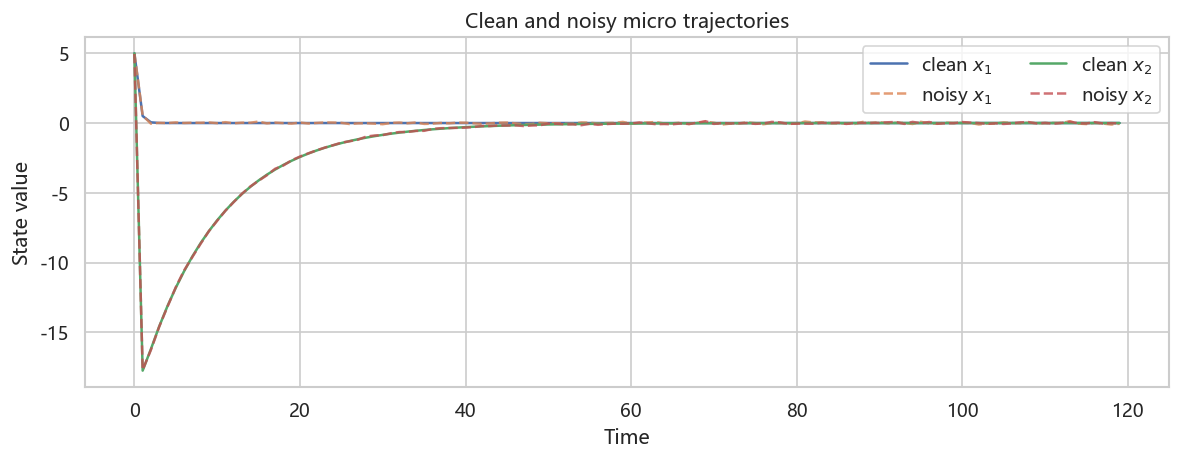

In [24]:
data_clean, x_data_raw, base_noise, t_data_raw = gen_step_data_with_noise(
    initial_x=analysis_config['dynamics']['initial_x'],
    initial_y=analysis_config['dynamics']['initial_y'],
    lam=analysis_config['dynamics']['lam'],
    mu=analysis_config['dynamics']['mu'],
    total_steps=analysis_config['dynamics']['total_steps'],
    dt=analysis_config['dynamics']['dt'],
    noise_scale=analysis_config['dynamics']['noise_scale'],
    random_seed=analysis_config['dynamics']['noise_seed'],
)
state_names_raw = ['$x_1$', '$x_2$']
K_direct_reference = K_direct.copy()

artifacts['raw'] = {
    'x_data_raw': x_data_raw,
    'data_clean': data_clean,
    'base_noise': base_noise,
    't_data_raw': t_data_raw,
    'state_names_raw': state_names_raw,
    'K_direct_reference': K_direct_reference,
}

print('Raw noisy data shape:', x_data_raw.shape)
print('Raw clean data shape:', data_clean.shape)
print('Noise source: standard normal N(0, 1) with scale =', analysis_config['dynamics']['noise_scale'])
print('Reference direct K shape:', K_direct_reference.shape)

plt.figure(figsize=(10, 4))
plt.plot(t_data_raw[:120], data_clean[:120, 0], label='clean $x_1$')
plt.plot(t_data_raw[:120], x_data_raw[:120, 0], '--', alpha=0.8, label='noisy $x_1$')
plt.plot(t_data_raw[:120], data_clean[:120, 1], label='clean $x_2$')
plt.plot(t_data_raw[:120], x_data_raw[:120, 1], '--', alpha=0.8, label='noisy $x_2$')
plt.title('Clean and noisy micro trajectories')
plt.xlabel('Time')
plt.ylabel('State value')
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


### 数据整理与 lift

为了让第二部分和第三部分可以直接对照，这里仍然使用 `[x_1, x_2, x_1^2]` 作为提升后的观测坐标。


In [25]:
burn_in_steps = analysis_config['burn_in_steps']
sample_stride = analysis_config['sample_stride']

x_data_fit = x_data_raw[burn_in_steps::sample_stride].copy()
t_data_fit = t_data_raw[burn_in_steps::sample_stride].copy()
state_names_fit = state_names_raw.copy()
dt_fit = analysis_config['dynamics']['dt'] * sample_stride
tau = analysis_config['lag_steps'] * dt_fit

library_functions = [
    lambda x: x,
    lambda x, y: x * x,
]
library = ps.CustomLibrary(library_functions=library_functions)
library.fit(x_data_fit)
x_data_lift = np.asarray(library.transform(x_data_fit), dtype=float)
feature_names = library.get_feature_names(input_features=state_names_fit)
x_data_lift_centered = np.asarray(x_data_lift - np.mean(x_data_lift, axis=0, keepdims=True), dtype=float)

artifacts['prep'] = {
    'x_data_fit': x_data_fit,
    't_data_fit': t_data_fit,
    'state_names_fit': state_names_fit,
    'dt_fit': dt_fit,
    'tau': tau,
}
artifacts['obs'] = {
    'library': library,
    'x_data_lift': x_data_lift,
    'x_data_lift_centered': x_data_lift_centered,
    'feature_names': feature_names,
}

print('Prepared data shape:', x_data_fit.shape)
print('dt_fit:', dt_fit)
print('tau:', tau)
print('Feature names:', feature_names)


Prepared data shape: (590, 2)
dt_fit: 1.0
tau: 1.0
Feature names: ['f0($x_1$)', 'f0($x_2$)', 'f1($x_1$,$x_2$)']


### 协方差矩阵、K_raw 与 K_bar

这一块对数据配对后计算 C00、C01、C11，并生成 K_raw 与白化后的 K_bar。后续指标主要围绕 K_bar 展开。


Pair count: 589
C00 shape: (3, 3)
C01 shape: (3, 3)
C11 shape: (3, 3)


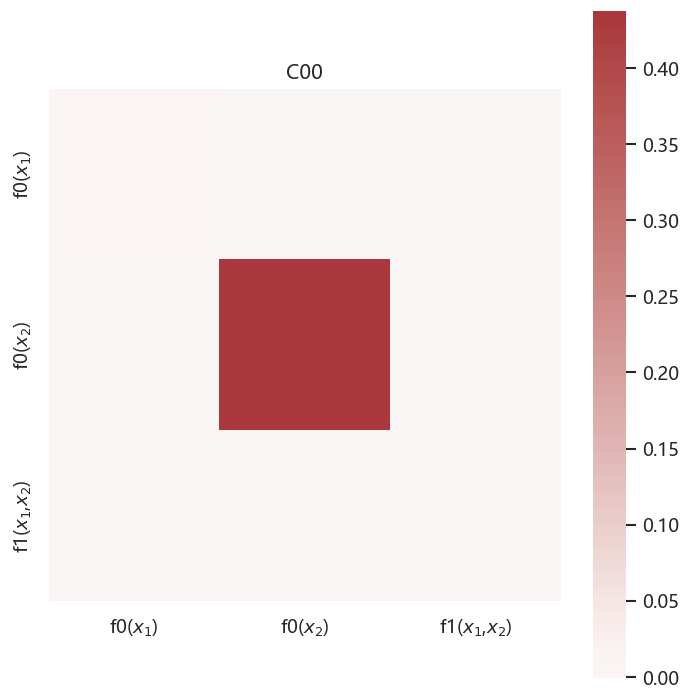

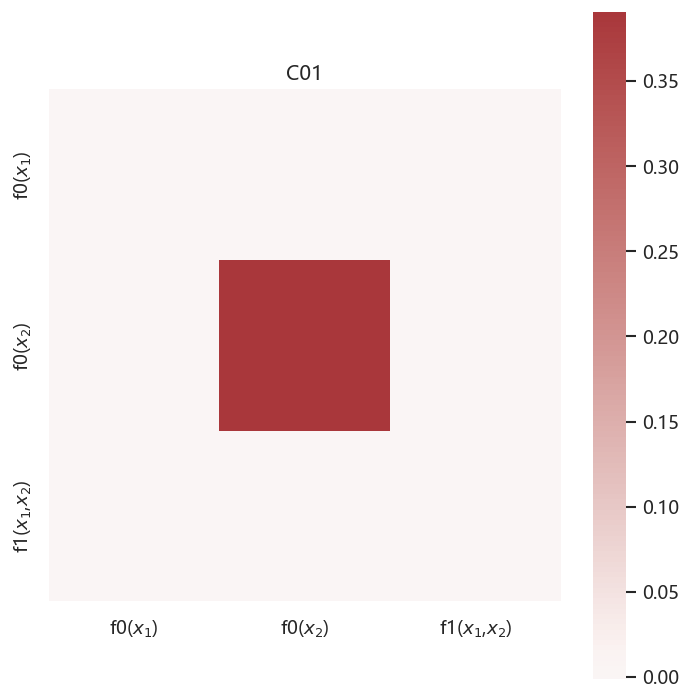

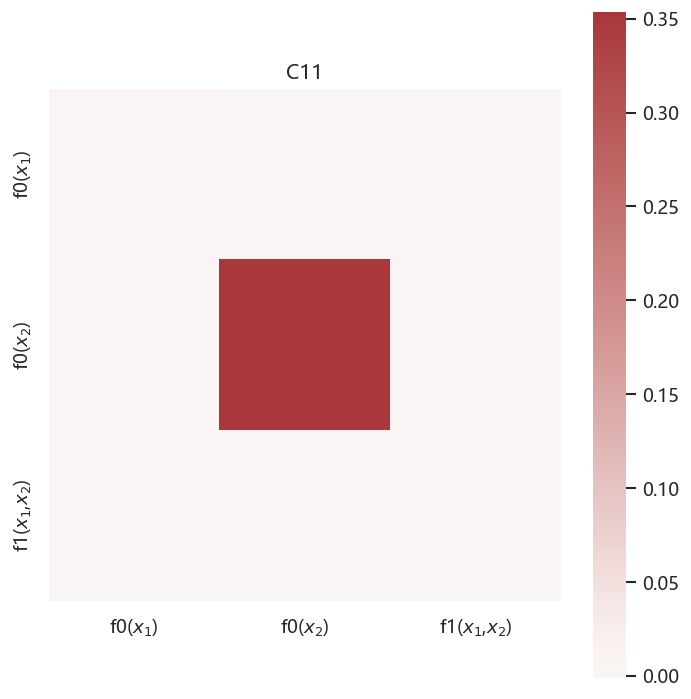

K_raw shape: (3, 3)
K_bar shape: (3, 3)
sigma_max(K_bar): 0.9938699864703159


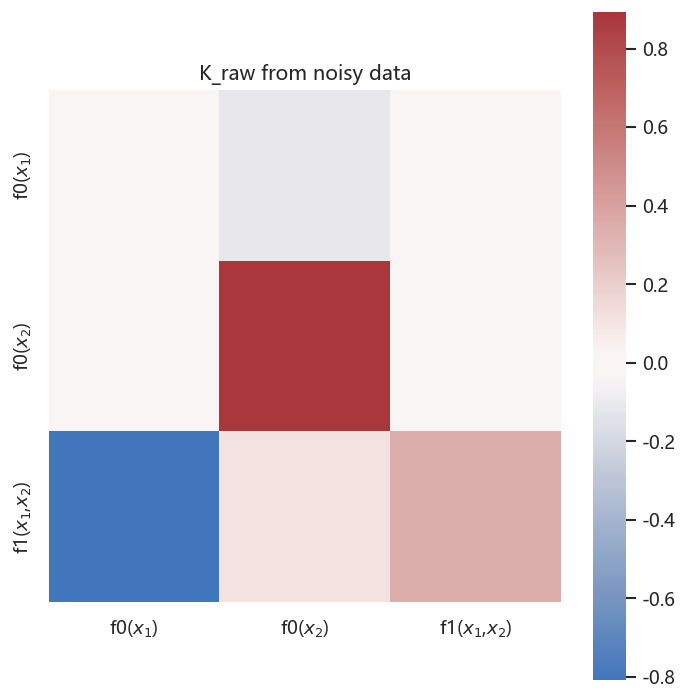

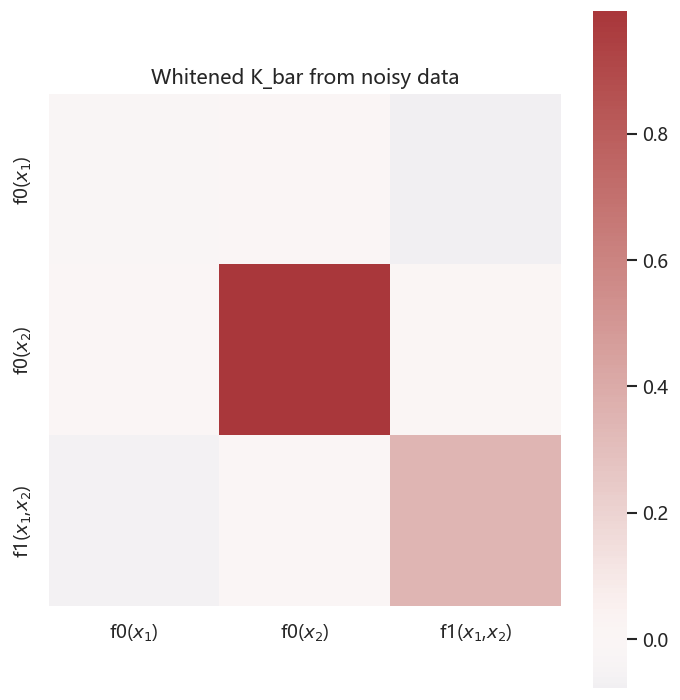

In [26]:
transition_stats = compute_transition_covariances([x_data_lift], library=None, weights='uniform', lag_steps=analysis_config['lag_steps'])

C00 = transition_stats['C00']
C01 = transition_stats['C01']
C11 = transition_stats['C11']
X_pairs = transition_stats['X']
Y_pairs = transition_stats['Y']

artifacts['cov'] = {
    'transition_stats': transition_stats,
    'C00': C00,
    'C01': C01,
    'C11': C11,
    'X_pairs': X_pairs,
    'Y_pairs': Y_pairs,
}

print('Pair count:', X_pairs.shape[0])
print('C00 shape:', C00.shape)
print('C01 shape:', C01.shape)
print('C11 shape:', C11.shape)

plot_matrix_heatmap(C00, 'C00', row_labels=feature_names, col_labels=feature_names, label_step=1)
plot_matrix_heatmap(C01, 'C01', row_labels=feature_names, col_labels=feature_names, label_step=1)
plot_matrix_heatmap(C11, 'C11', row_labels=feature_names, col_labels=feature_names, label_step=1)

koop_fit = fit_data_koopman_operator([x_data_lift], library=None, weights='uniform', eps=analysis_config['eps'], ridge=analysis_config['ridge'], lag_steps=analysis_config['lag_steps'])
K_raw = koop_fit['A']
K_bar = koop_fit['K_bar']
C00_inv_sqrt = koop_fit['C00_inv_sqrt']
C11_inv_sqrt = koop_fit['C11_inv_sqrt']

artifacts['koopman'] = {
    'koop_fit': koop_fit,
    'K_raw': K_raw,
    'K_bar': K_bar,
    'C00_inv_sqrt': C00_inv_sqrt,
    'C11_inv_sqrt': C11_inv_sqrt,
}

print('K_raw shape:', K_raw.shape)
print('K_bar shape:', K_bar.shape)
print('sigma_max(K_bar):', np.linalg.svd(K_bar, compute_uv=False)[0])

plot_matrix_heatmap(K_raw, 'K_raw from noisy data', row_labels=feature_names, col_labels=feature_names, label_step=1)
plot_matrix_heatmap(K_bar, 'Whitened K_bar from noisy data', row_labels=feature_names, col_labels=feature_names, label_step=1)


### K_bar 的谱结构、EC、D_K/N_K 与 CE

这一块完整沿用 Kuramoto 0321 主链中的指标系统。


Singular values of K_bar: [0.99386999 0.35522097 0.03289726]
EC of K_bar: 0.9321046450543651
G_alpha^K of K_bar: 0.04245829937309664
Selected r from CE: 1
Delta Gamma at selected r: 0.5332072493335138


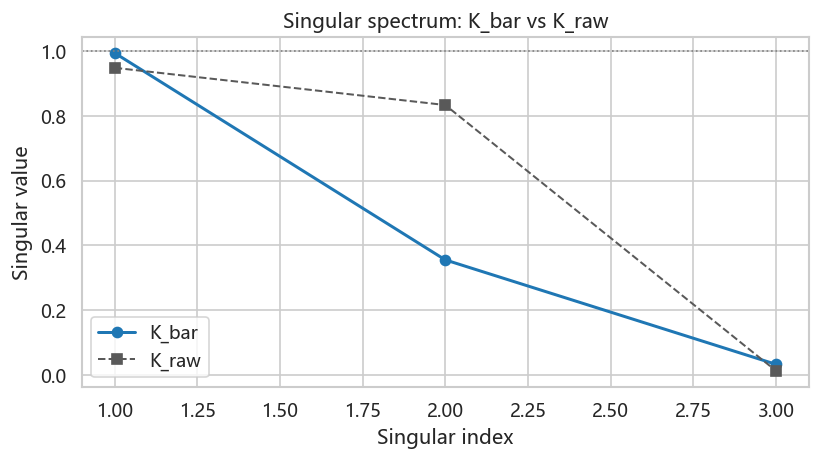

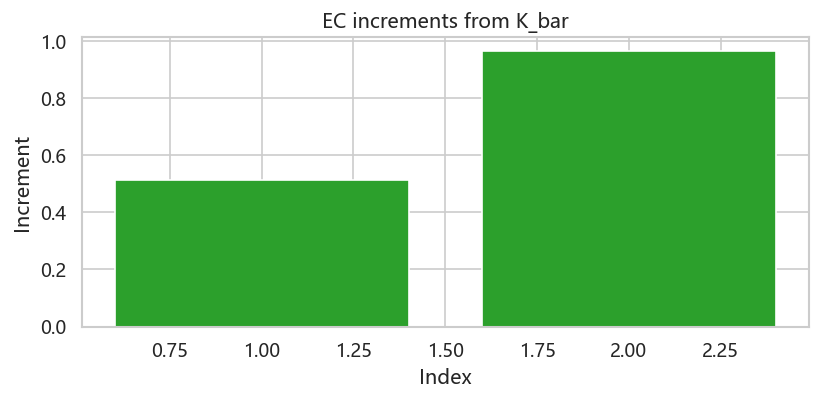

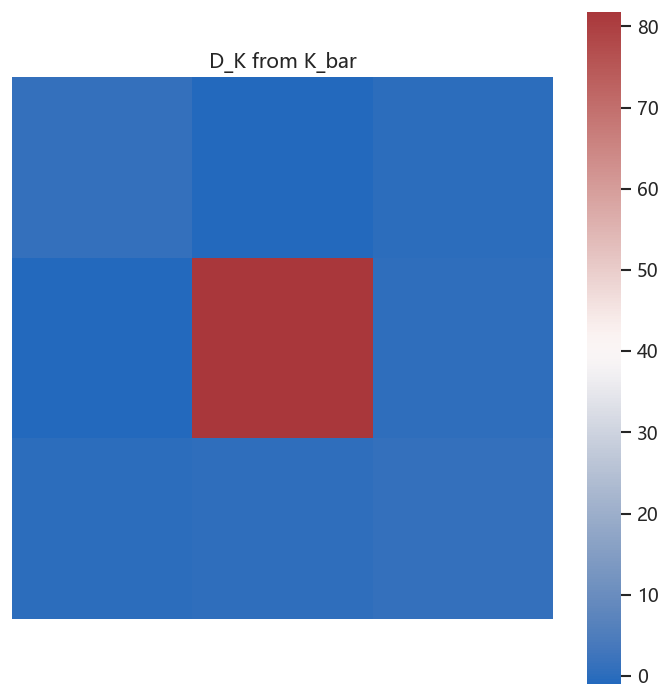

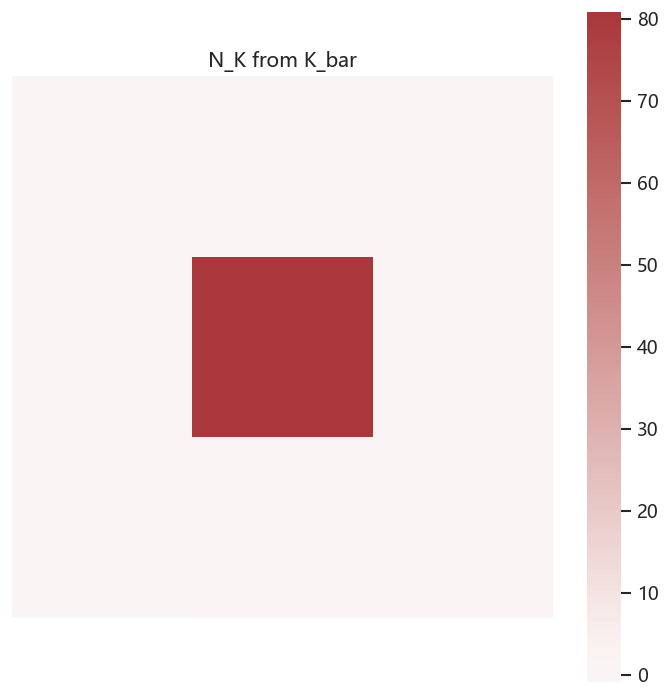

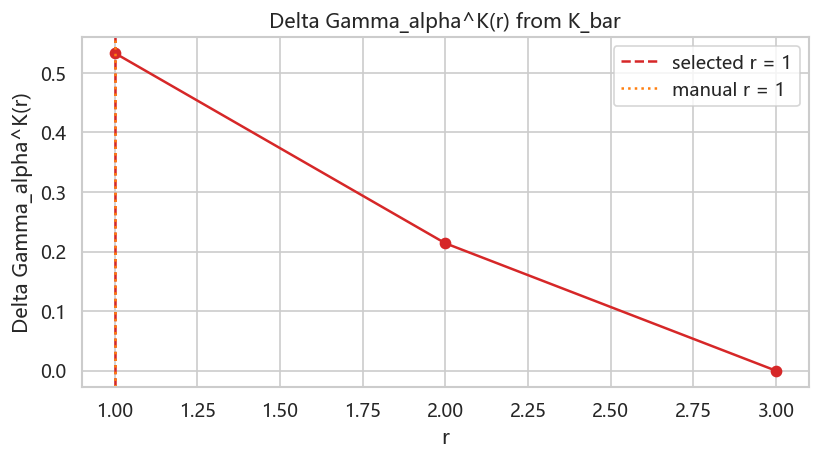

In [27]:
U_raw, S_raw, Vt_raw = np.linalg.svd(K_raw, full_matrices=False)
metrics = analyze_kbar_metrics(K_bar, alpha=analysis_config['alpha'], eps=analysis_config['eps'])
U_bar = metrics['U']
S_bar = metrics['S']
Vt_bar = metrics['Vt']

diff = get_positive_contributions(S_bar)
EC = compute_entropy(diff)

gamma_metrics = compute_gamma_ce_metrics(S_bar, alpha=analysis_config['alpha'], rank_candidates=analysis_config['rank_candidates'], manual_r=analysis_config['rank'], eps=analysis_config['eps'])

artifacts['spectral'] = {
    'U_raw': U_raw,
    'S_raw': S_raw,
    'Vt_raw': Vt_raw,
    'U_bar': U_bar,
    'S_bar': S_bar,
    'Vt_bar': Vt_bar,
    'diff': diff,
    'EC': EC,
}
artifacts['metrics'].update(metrics)
artifacts['metrics']['EC'] = EC
artifacts['metrics']['gamma_metrics'] = gamma_metrics

print('Singular values of K_bar:', S_bar)
print('EC of K_bar:', EC)
print('G_alpha^K of K_bar:', metrics['G_alpha_K'])
print('Selected r from CE:', gamma_metrics['selected_r'])
print('Delta Gamma at selected r:', gamma_metrics['delta_gamma_selected_r'])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, len(S_bar) + 1), S_bar, marker='o', linewidth=1.8, label='K_bar', color='tab:blue')
ax.plot(np.arange(1, len(S_raw) + 1), S_raw, marker='s', linewidth=1.2, linestyle='--', label='K_raw', color='0.35')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.0)
ax.set_title('Singular spectrum: K_bar vs K_raw')
ax.set_xlabel('Singular index')
ax.set_ylabel('Singular value')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(np.arange(1, len(diff) + 1), diff, color='tab:green')
ax.set_title('EC increments from K_bar')
ax.set_xlabel('Index')
ax.set_ylabel('Increment')
plt.tight_layout()
plt.show()

plot_matrix_heatmap(metrics['D_K'], 'D_K from K_bar', center=None, label_step=1)
plot_matrix_heatmap(metrics['N_K'], 'N_K from K_bar', center=0.0, label_step=1)

plt.figure(figsize=(7, 4))
plt.plot(list(gamma_metrics['delta_gamma_by_r'].keys()), list(gamma_metrics['delta_gamma_by_r'].values()), marker='o', color='tab:red')
plt.axvline(gamma_metrics['selected_r'], color='tab:red', linestyle='--', label=f"selected r = {gamma_metrics['selected_r']}")
if gamma_metrics['manual_r'] is not None:
    plt.axvline(gamma_metrics['manual_r'], color='tab:orange', linestyle=':', label=f"manual r = {gamma_metrics['manual_r']}")
plt.title('Delta Gamma_alpha^K(r) from K_bar')
plt.xlabel('r')
plt.ylabel('Delta Gamma_alpha^K(r)')
plt.legend()
plt.tight_layout()
plt.show()


### K_bar 的粗粒化表达式与宏观对比

这里使用 K_bar 的前 r 个左奇异向量构造宏观变量，并给出粗粒化表达式、宏观方程和宏微观对照。


Macro variables are constructed using selected_r = 1
Macro current shape: (589, 1)
Top features per macro component:
Component 1:


,feature,weight,abs_weight
0,f0($x_2$),-1.512557,1.512557
1,"f1($x_1$,$x_2$)",-0.936455,0.936455
2,f0($x_1$),0.193296,0.193296


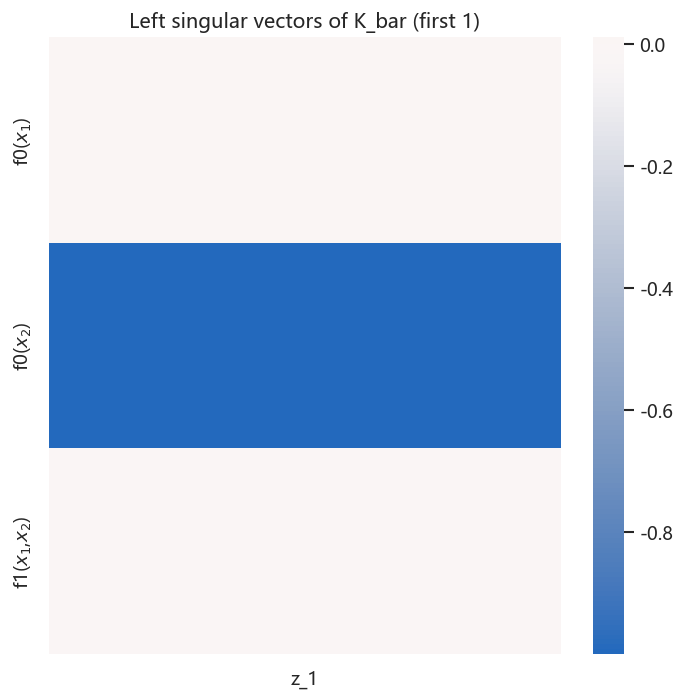

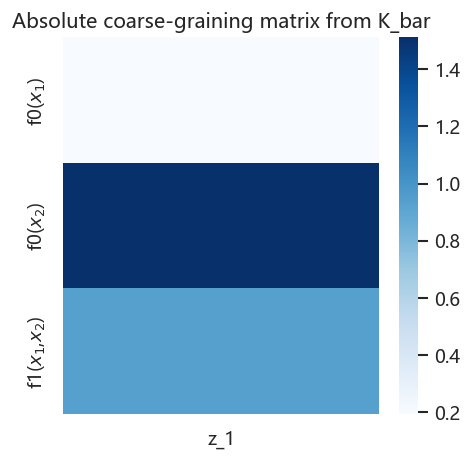

Coarse-graining expressions from K_bar:
z_1 = 0.1933 * f0($x_1$) + -1.5126 * f0($x_2$) + -0.9365 * f1($x_1$,$x_2$)
----------------------------------------
Macro evolution equation from K_bar:
z_1[k+1] = 0.9939 * z_1
----------------------------------------


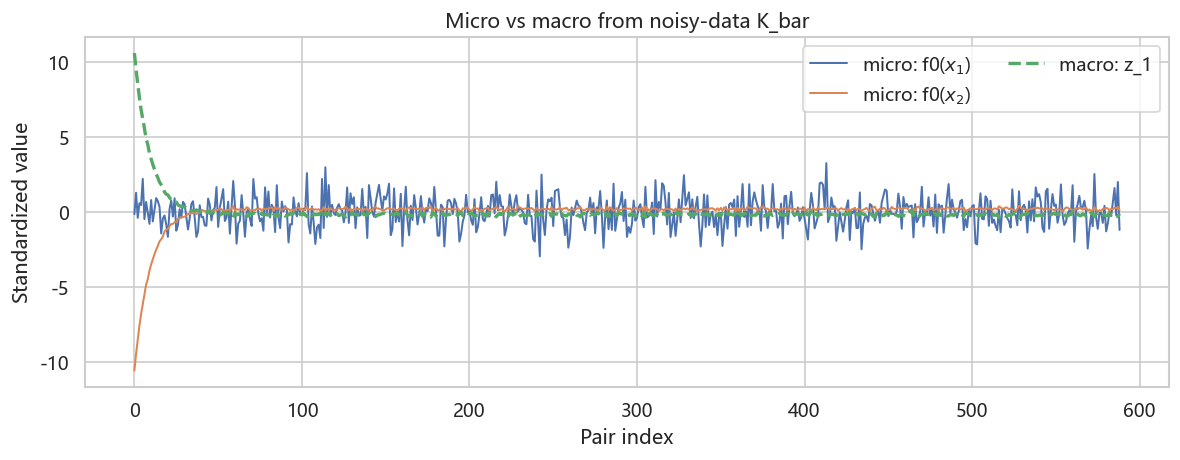

In [28]:
macro_r_mode = analysis_config.get('macro_r_mode', 'selected')
if macro_r_mode == 'manual' and gamma_metrics['manual_r'] is not None:
    macro_r = gamma_metrics['manual_r']
    macro_r_source = f"manual_r = {gamma_metrics['manual_r']}"
else:
    macro_r = gamma_metrics['selected_r']
    macro_r_source = f"selected_r = {gamma_metrics['selected_r']}"

macro = build_macro_from_kbar(U=U_bar, S=S_bar, Vt=Vt_bar, C00_inv_sqrt=C00_inv_sqrt, X=X_pairs, r=macro_r, feature_names=feature_names, Y=Y_pairs, C11_inv_sqrt=C11_inv_sqrt, center=False)

z_current = macro['z_current']
macro_names = [f'z_{i+1}' for i in range(macro_r)]
A_macro = macro['U_r'].T @ K_bar @ macro['U_r']

artifacts['macro'] = macro
artifacts['metrics']['macro_r'] = macro_r
artifacts['metrics']['macro_r_source'] = macro_r_source

print('Macro variables are constructed using', macro_r_source)
print('Macro current shape:', z_current.shape)
print('Top features per macro component:')
for idx, items in enumerate(macro['dominant_features'], start=1):
    print(f'Component {idx}:')
    display(pd.DataFrame(items))

plot_matrix_heatmap(U_bar[:, :macro_r], f'Left singular vectors of K_bar (first {macro_r})', row_labels=feature_names, col_labels=macro_names, label_step=1)
plot_matrix_heatmap(np.abs(macro['coarse_grain_matrix']), 'Absolute coarse-graining matrix from K_bar', row_labels=feature_names, col_labels=macro_names, center=None, figsize=(4, 4), label_step=1, cmap='Blues')

print('Coarse-graining expressions from K_bar:')
print_linear_combination(macro['coarse_grain_matrix'], feature_names, macro_names)
print('Macro evolution equation from K_bar:')
print_linear_combination(A_macro, macro_names, [f'{name}[k+1]' for name in macro_names])

plt.figure(figsize=(10, 4))
for idx in analysis_config['selected_micro_indices']:
    plt.plot(standardize_for_plot(X_pairs[:, idx]), linewidth=1.2, label=f'micro: {feature_names[idx]}')
for i in range(macro_r):
    plt.plot(standardize_for_plot(z_current[:, i]), '--', linewidth=2.0, label=f'macro: {macro_names[i]}')
plt.title('Micro vs macro from noisy-data K_bar')
plt.xlabel('Pair index')
plt.ylabel('Standardized value')
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


## 4. 奇异值与特征值的对比：step2 系统

这一部分使用原 analytic notebook 中的 `step2` 动力学例子。它的特点是 K 矩阵可以直接写出，因此很适合用来对比奇异值分解与特征值分解对宏观表示的影响。


step2 K matrix:
[[ 0.8   0.   10.  ]
 [ 0.    0.8   0.  ]
 [ 0.    0.    0.64]]
step2 singular values: [10.05221397  0.8         0.05093405]
step2 eigenvalues: [0.8  0.8  0.64]


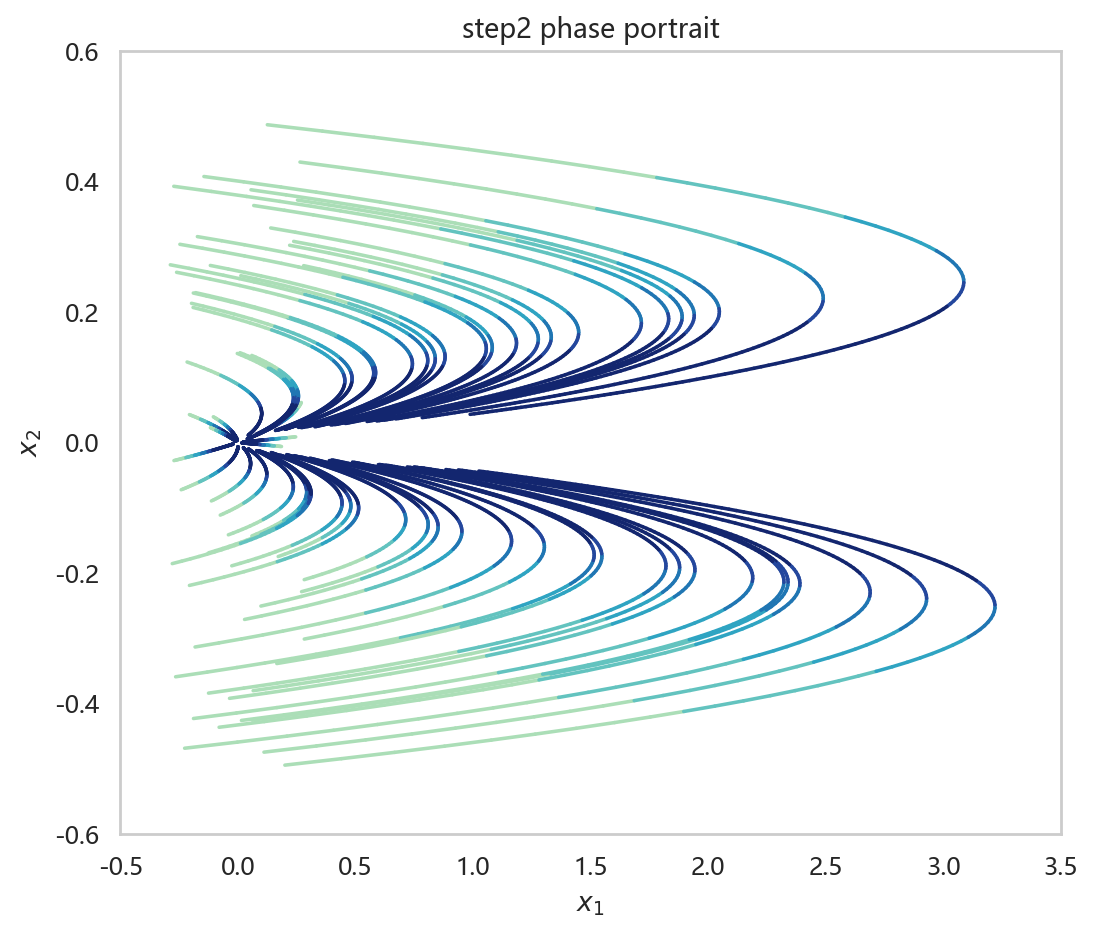

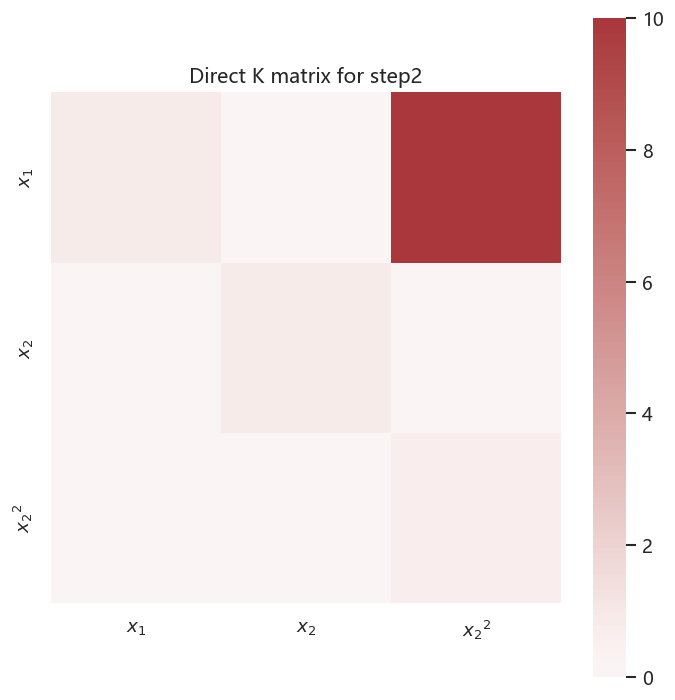

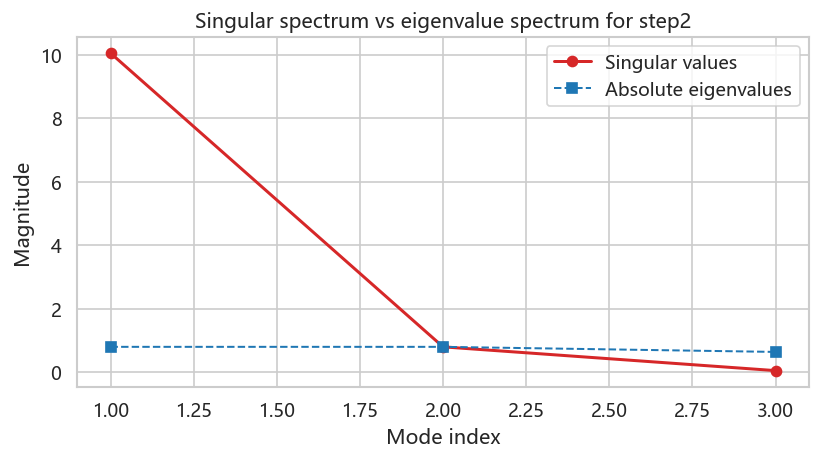

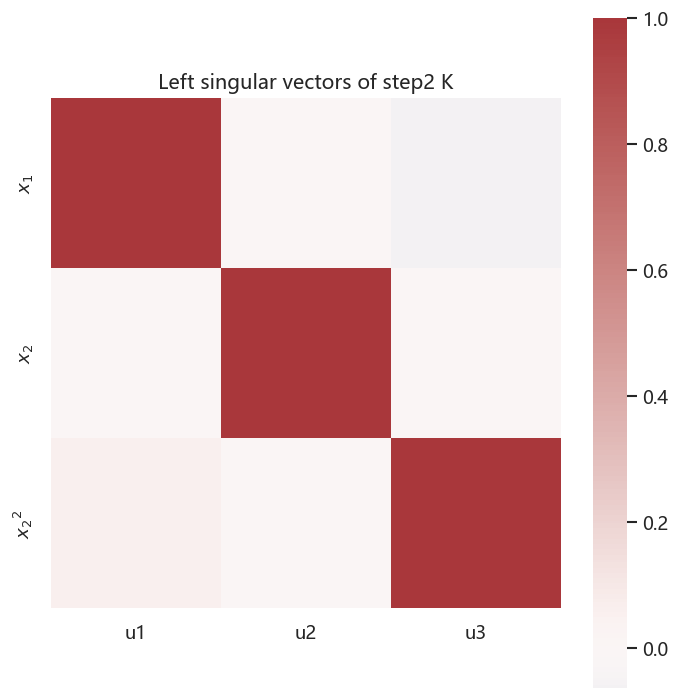

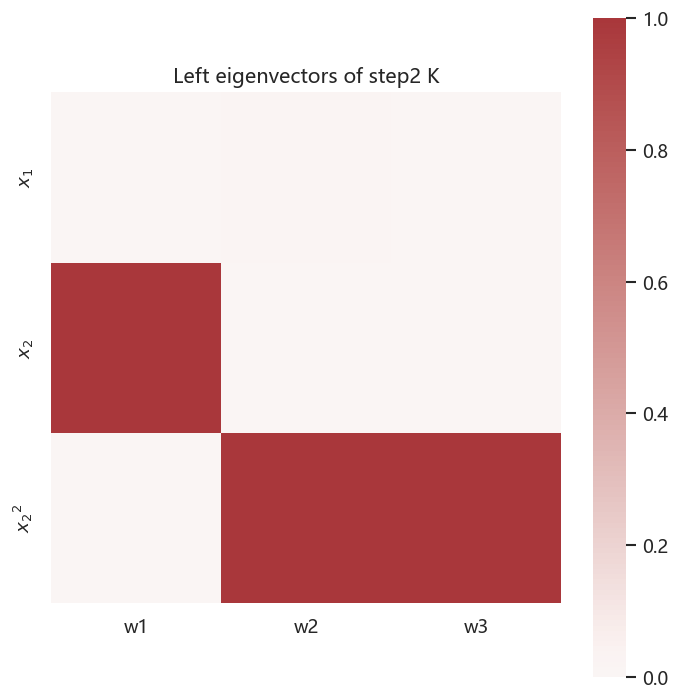

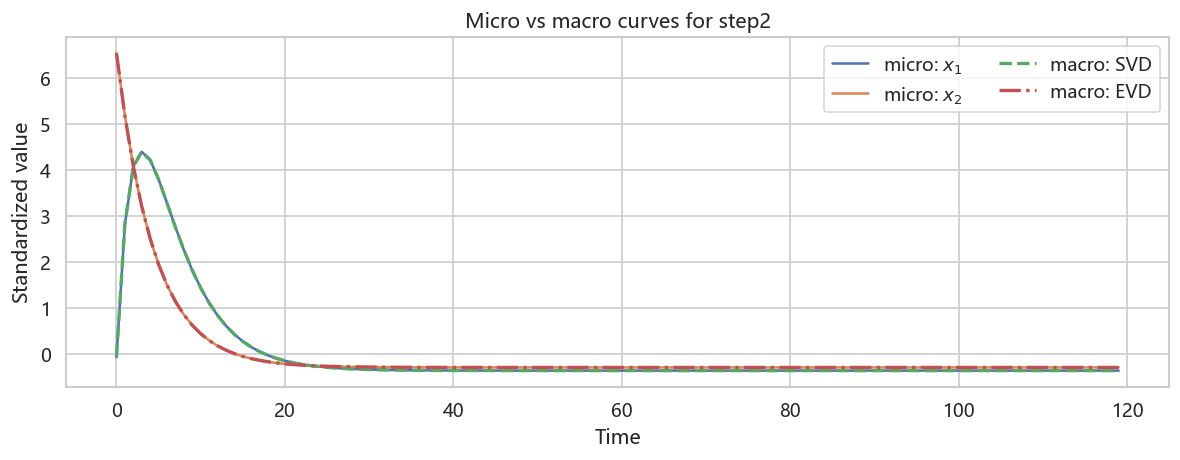

,mode,singular_value,left_eigenvalue_abs,left_eigenvalue_real,left_eigenvalue_imag
0,1,10.052214,0.80,0.80,0.0
1,2,0.800000,0.80,0.80,0.0
2,3,0.050934,0.64,0.64,0.0


In [29]:
def step2(x, y):
    """
    根据给定的方程计算下一步状态:
    x_{k+1} = 0.8 * x_k + 10 * y_k^2
    y_{k+1} = 0.8 * y_k
    """
    x_next = 0.8 * x + 10 * (y ** 2)
    y_next = 0.8 * y
    return x_next, y_next


def gen_step2_data(initial_x=0.2, initial_y=0.4, total_steps=200, dt=1.0):
    t = np.arange(0, total_steps * dt, dt)
    x_vals = np.zeros(len(t))
    y_vals = np.zeros(len(t))
    x_vals[0], y_vals[0] = initial_x, initial_y
    for i in range(1, len(t)):
        x_vals[i], y_vals[i] = step2(x_vals[i - 1], y_vals[i - 1])
    return np.column_stack([x_vals, y_vals]), t

step2_feature_names = ['$x_1$', '$x_2$', '${x_2}^2$']
K_step2 = np.array([
    [0.8, 0.0, 10.0],
    [0.0, 0.8, 0.0],
    [0.0, 0.0, 0.64],
], dtype=float)

step2_metrics = analyze_kbar_metrics(K_step2, alpha=1.0, eps=1e-10)
U_step2 = step2_metrics['U']
S_step2 = step2_metrics['S']
left_eigvals_step2, left_eigvecs_step2 = np.linalg.eig(K_step2.T)
left_order = np.argsort(np.abs(left_eigvals_step2))[::-1]
left_eigvals_step2 = left_eigvals_step2[left_order]
left_eigvecs_step2 = left_eigvecs_step2[:, left_order]

# Normalize left eigenvectors for visualization and macro construction.
left_eigvecs_step2_real = np.real_if_close(left_eigvecs_step2)
left_eigvecs_step2_real = left_eigvecs_step2_real / (np.linalg.norm(left_eigvecs_step2_real, axis=0, keepdims=True) + 1e-12)

step2_data, step2_t = gen_step2_data(initial_x=0.2, initial_y=0.45, total_steps=180, dt=1.0)
step2_lift = np.column_stack([step2_data[:, 0], step2_data[:, 1], step2_data[:, 1] ** 2])
svd_macro_step2 = step2_lift @ U_step2[:, :1]
eig_macro_step2 = step2_lift @ left_eigvecs_step2_real[:, :1]

print('step2 K matrix:')
print(K_step2)
print('step2 singular values:', S_step2)
print('step2 eigenvalues:', left_eigvals_step2)

# Phase portrait with gradient trajectories.
fig, ax = plt.subplots(figsize=(7, 6), dpi=160)
np.random.seed(42)
init_x = np.random.uniform(-0.3, 0.3, 60)
init_y = np.random.uniform(-0.5, 0.5, 60)
initial_points = np.vstack([init_x, init_y]).T
colors = plt.cm.YlGnBu(np.linspace(0.3, 0.95, 6))
custom_cmap = ListedColormap(colors)
for x0, y0 in initial_points:
    xs, ys = [x0], [y0]
    curr_x, curr_y = x0, y0
    for _ in range(120):
        next_x, next_y = step2(curr_x, curr_y)
        dx = next_x - curr_x
        dy = next_y - curr_y
        curr_x = curr_x + 0.1 * dx
        curr_y = curr_y + 0.1 * dy
        xs.append(curr_x)
        ys.append(curr_y)
    points = np.array([xs, ys]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    color_indices = np.arange(len(segments))
    color_indices[50:] = 50
    lc = LineCollection(segments, cmap=custom_cmap)
    lc.set_array(color_indices)
    lc.set_linewidth(1.6)
    lc.set_capstyle('round')
    ax.add_collection(lc)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('step2 phase portrait')
ax.set_xlim([-0.5, 3.5])
ax.set_ylim([-0.6, 0.6])
ax.grid(False)
plt.tight_layout()
plt.show()

plot_matrix_heatmap(K_step2, 'Direct K matrix for step2', row_labels=step2_feature_names, col_labels=step2_feature_names, label_step=1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, len(S_step2) + 1), S_step2, marker='o', linewidth=1.8, label='Singular values', color='tab:red')
ax.plot(np.arange(1, len(left_eigvals_step2) + 1), np.abs(left_eigvals_step2), marker='s', linewidth=1.2, linestyle='--', label='Absolute eigenvalues', color='tab:blue')
ax.set_title('Singular spectrum vs eigenvalue spectrum for step2')
ax.set_xlabel('Mode index')
ax.set_ylabel('Magnitude')
ax.legend()
plt.tight_layout()
plt.show()

plot_matrix_heatmap(U_step2, 'Left singular vectors of step2 K', row_labels=step2_feature_names, col_labels=[f'u{i+1}' for i in range(U_step2.shape[1])], label_step=1)
plot_matrix_heatmap(left_eigvecs_step2_real, 'Left eigenvectors of step2 K', row_labels=step2_feature_names, col_labels=[f'w{i+1}' for i in range(left_eigvecs_step2_real.shape[1])], label_step=1)

plt.figure(figsize=(10, 4))
plt.plot(step2_t[:120], standardize_for_plot(step2_lift[:120, 0]), label='micro: $x_1$')
plt.plot(step2_t[:120], standardize_for_plot(step2_lift[:120, 1]), label='micro: $x_2$')
plt.plot(step2_t[:120], standardize_for_plot(svd_macro_step2[:120, 0]), '--', linewidth=2.0, label='macro: SVD')
plt.plot(step2_t[:120], standardize_for_plot(eig_macro_step2[:120, 0]), '-.', linewidth=2.0, label='macro: EVD')
plt.title('Micro vs macro curves for step2')
plt.xlabel('Time')
plt.ylabel('Standardized value')
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

step2_summary = pd.DataFrame({
    'mode': np.arange(1, len(S_step2) + 1),
    'singular_value': S_step2,
    'left_eigenvalue_abs': np.abs(left_eigvals_step2),
    'left_eigenvalue_real': np.real(left_eigvals_step2),
    'left_eigenvalue_imag': np.imag(left_eigvals_step2),
})
display(step2_summary)


## 5. 解析 K 与噪声数据白化 K_bar 的对比

这一部分将第二部分的解析 K、第三部分的 K_raw 以及白化 K_bar 放在同一套视角下比较。重点包括矩阵本身、奇异值谱、EC、CE 与相关主指标。


,matrix_name,shape,sigma_max,EC,G_alpha_K,Gamma_alpha_K,gamma_alpha_K,selected_r,selected_CE,manual_r,manual_CE
0,direct_K,"(3, 3)",1.26576,0.999866,-3.619344,1.372871,0.457624,1,0.808137,1,0.808137
1,noisy_data_K_bar,"(3, 3)",0.99387,0.932105,0.042458,1.381988,0.460663,1,0.533207,1,0.533207


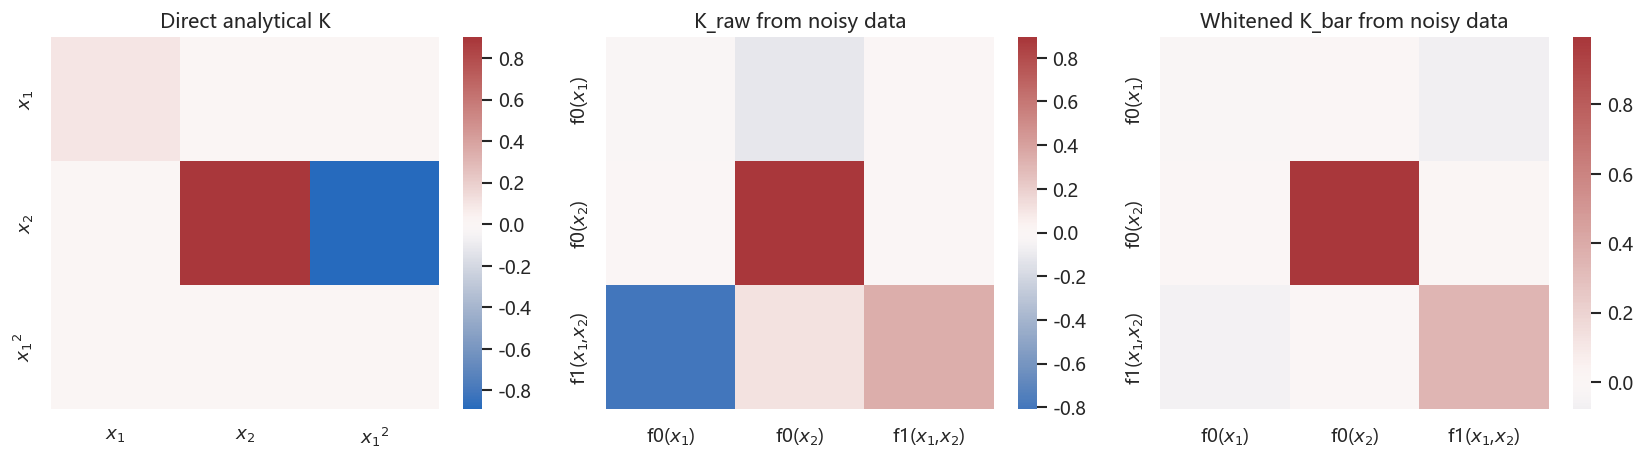

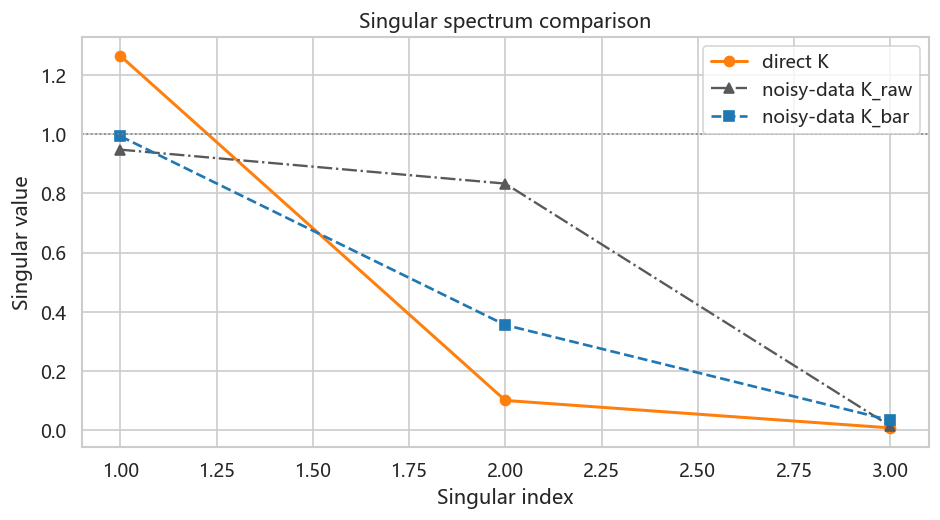

,metric,direct_K,noisy_data_K_bar
0,EC,0.999866,0.932105
1,selected CE,0.808137,0.533207
2,manual CE,0.808137,0.533207
3,G_alpha^K,-3.619344,0.042458
4,Gamma_alpha^K,1.372871,1.381988
5,gamma_alpha^K,0.457624,0.460663


In [30]:
comparison_df = pd.DataFrame([
    {
        'matrix_name': 'direct_K',
        'shape': str(K_direct.shape),
        'sigma_max': float(np.max(direct_metrics['S'])),
        'EC': float(direct_EC),
        'G_alpha_K': float(direct_metrics['G_alpha_K']),
        'Gamma_alpha_K': float(direct_gamma['Gamma_alpha_K']),
        'gamma_alpha_K': float(direct_gamma['gamma_alpha_K']),
        'selected_r': int(direct_gamma['selected_r']),
        'selected_CE': float(direct_gamma['delta_gamma_selected_r']),
        'manual_r': int(direct_gamma['manual_r']),
        'manual_CE': float(direct_gamma['delta_gamma_manual_r']),
    },
    {
        'matrix_name': 'noisy_data_K_bar',
        'shape': str(K_bar.shape),
        'sigma_max': float(np.max(S_bar)),
        'EC': float(EC),
        'G_alpha_K': float(metrics['G_alpha_K']),
        'Gamma_alpha_K': float(gamma_metrics['Gamma_alpha_K']),
        'gamma_alpha_K': float(gamma_metrics['gamma_alpha_K']),
        'selected_r': int(gamma_metrics['selected_r']),
        'selected_CE': float(gamma_metrics['delta_gamma_selected_r']),
        'manual_r': int(gamma_metrics['manual_r']),
        'manual_CE': float(gamma_metrics['delta_gamma_manual_r']),
    },
])
display(comparison_df)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.heatmap(K_direct, ax=axes[0], cmap=HEATMAP_CMAP, center=0.0, xticklabels=direct_feature_names, yticklabels=direct_feature_names)
axes[0].set_title('Direct analytical K')
sns.heatmap(K_raw, ax=axes[1], cmap=HEATMAP_CMAP, center=0.0, xticklabels=feature_names, yticklabels=feature_names)
axes[1].set_title('K_raw from noisy data')
sns.heatmap(K_bar, ax=axes[2], cmap=HEATMAP_CMAP, center=0.0, xticklabels=feature_names, yticklabels=feature_names)
axes[2].set_title('Whitened K_bar from noisy data')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(1, len(direct_metrics['S']) + 1), direct_metrics['S'], marker='o', linewidth=1.8, label='direct K', color='tab:orange')
ax.plot(np.arange(1, len(S_raw) + 1), S_raw, marker='^', linewidth=1.4, linestyle='-.', label='noisy-data K_raw', color='0.35')
ax.plot(np.arange(1, len(S_bar) + 1), S_bar, marker='s', linewidth=1.6, linestyle='--', label='noisy-data K_bar', color='tab:blue')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.0)
ax.set_title('Singular spectrum comparison')
ax.set_xlabel('Singular index')
ax.set_ylabel('Singular value')
ax.legend()
plt.tight_layout()
plt.show()

metric_compare = pd.DataFrame({
    'metric': ['EC', 'selected CE', 'manual CE', 'G_alpha^K', 'Gamma_alpha^K', 'gamma_alpha^K'],
    'direct_K': [direct_EC, direct_gamma['delta_gamma_selected_r'], direct_gamma['delta_gamma_manual_r'], direct_metrics['G_alpha_K'], direct_gamma['Gamma_alpha_K'], direct_gamma['gamma_alpha_K']],
    'noisy_data_K_bar': [EC, gamma_metrics['delta_gamma_selected_r'], gamma_metrics['delta_gamma_manual_r'], metrics['G_alpha_K'], gamma_metrics['Gamma_alpha_K'], gamma_metrics['gamma_alpha_K']],
})
display(metric_compare)


## 统一摘要

最后用一个统一摘要把解析 K、噪声数据 K_bar 以及 step2 中的奇异值/特征值对比结果放在一起。


In [31]:
summary_dict = {
    'experiment': {
        'name': analysis_config['experiment_name'],
        'observable_mode': analysis_config['observable_mode'],
        'alpha': analysis_config['alpha'],
        'lag_steps': analysis_config['lag_steps'],
        'noise_scale': analysis_config['dynamics']['noise_scale'],
    },
    'direct_K': {
        'shape': K_direct.shape,
        'EC': direct_EC,
        'G_alpha_K': direct_metrics['G_alpha_K'],
        'selected_r': direct_gamma['selected_r'],
        'selected_CE': direct_gamma['delta_gamma_selected_r'],
    },
    'noisy_data_K_bar': {
        'shape': K_bar.shape,
        'EC': EC,
        'G_alpha_K': metrics['G_alpha_K'],
        'selected_r': gamma_metrics['selected_r'],
        'selected_CE': gamma_metrics['delta_gamma_selected_r'],
    },
    'step2_svd_evd': {
        'K_shape': K_step2.shape,
        'top_singular_value': float(S_step2[0]),
        'top_abs_eigenvalue': float(np.abs(left_eigvals_step2[0])),
        'second_abs_eigenvalue': float(np.abs(left_eigvals_step2[1])),
    },
}
print_summary(summary_dict)


Summary

[experiment]
           item                     value
           name         exp_analysis_0321
observable_mode custom: [x_1, x_2, x_1^2]
          alpha                       1.0
      lag_steps                         1
    noise_scale                      0.05

[direct_K]
       item     value
      shape    (3, 3)
         EC  0.999866
  G_alpha_K -3.619344
 selected_r         1
selected_CE  0.808137

[noisy_data_K_bar]
       item     value
      shape    (3, 3)
         EC  0.932105
  G_alpha_K  0.042458
 selected_r         1
selected_CE  0.533207

[step2_svd_evd]
                 item      value
              K_shape     (3, 3)
   top_singular_value  10.052214
   top_abs_eigenvalue        0.8
second_abs_eigenvalue        0.8
